In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [2]:
# Load the dataset and prepare the data
file_path = '../../data/Data3.csv'  # Update with your actual file path
data = pd.read_csv(file_path)
data['Site'] = data['ERBS'].str[:7]
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


C:\Users\HP\AppData\Local\Temp\ipykernel_12384\3504327335.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [3]:
# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [4]:
# Function to calculate MSE for each site
def calculate_mse_for_sites(target_column):
    mse_results = {}
    site_predictions = {}
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        if len(site_data) <= 10:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        X, y = create_sequences(site_data, seq_length=10)
        if len(X) == 0:
            print(f"Skipping site {site} because the sequence length is too long for the data.")
            continue

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results[site] = mse
        site_predictions[site] = (y_test, y_pred)
    
    return mse_results, site_predictions


In [5]:
# Calculate MSE and get predictions for DL_TRAFFIC_MB
mse_results_dl_traffic_mb, site_predictions_dl_traffic_mb = calculate_mse_for_sites('DL_TRAFFIC_MB')


1/1 [==============================] - 1s 1s/step
Skipping site BMBNC54 due to insufficient data.
3/3 [==============================] - 1s 4ms/step


In [6]:
# Sort results and get the best and worst 5 sites
sorted_mse_results = sorted(mse_results_dl_traffic_mb.items(), key=lambda x: x[1])
best_5_sites_dl = sorted_mse_results[:5]
worst_5_sites_dl = sorted_mse_results[-5:]

print("Best 5 Sites based on MSE for DL_TRAFFIC_MB:", best_5_sites_dl)
print("Worst 5 Sites based on MSE for DL_TRAFFIC_MB:", worst_5_sites_dl)

Best 5 Sites based on MSE for DL_TRAFFIC_MB: [('BMBNC49', 427843852.1087177), ('BMBNC55', 530570541.7631475), ('BMKSB57', 575355879.396727), ('BMBNC48', 627397676.5179888), ('BMKSB55', 627988240.6543669)]
Worst 5 Sites based on MSE for DL_TRAFFIC_MB: [('CXUKH40', 36609435449.879555), ('CXUKH38', 39068649184.769936), ('CXUKH64', 39703683395.23751), ('CXUKH39', 43664308279.346016), ('CXUKH62', 54986342194.930595)]


In [7]:
# Plot actual vs predicted values for the best and worst 5 sites
def plot_actual_vs_predicted(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for DL_TRAFFIC_MB - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

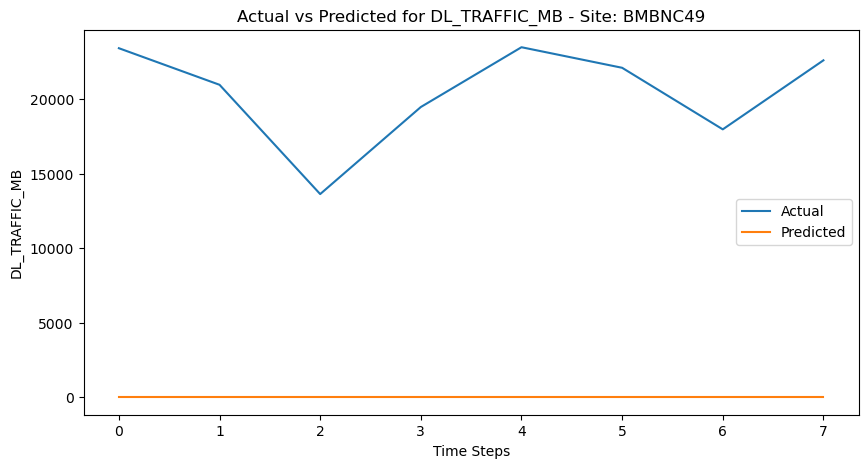

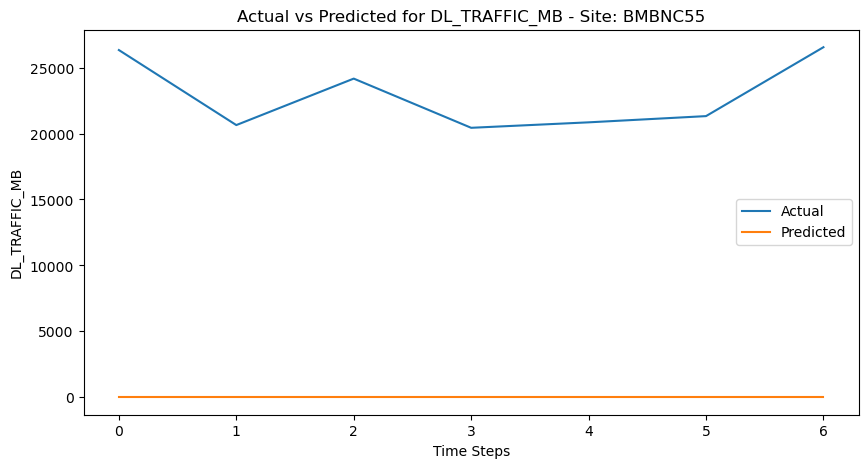

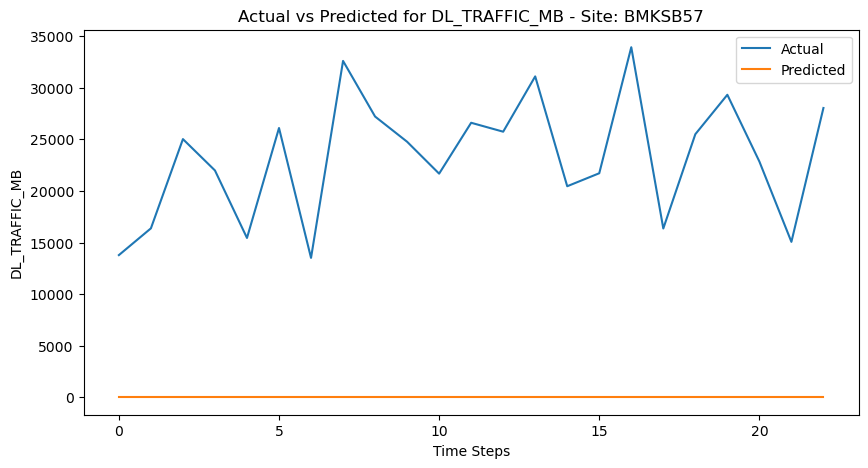

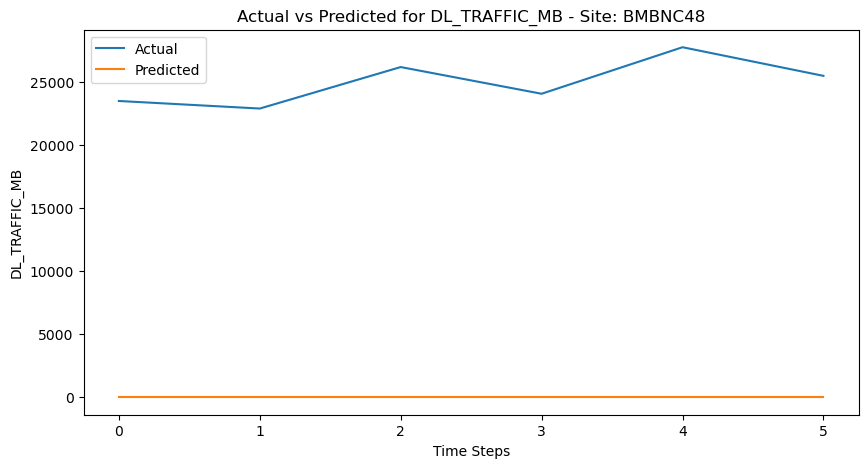

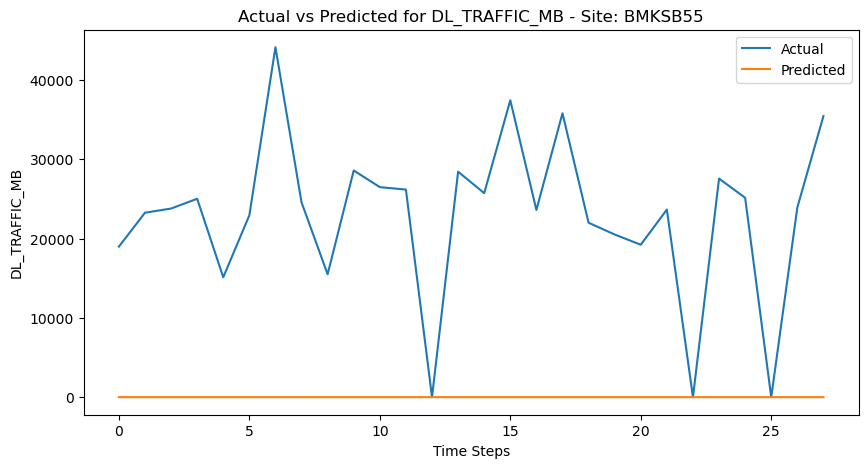

In [8]:
# Plot for the best 5 sites
for site, _ in best_5_sites_dl:
    if site in site_predictions_dl_traffic_mb:
        y_test, y_pred = site_predictions_dl_traffic_mb[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_dl_traffic_mb.")


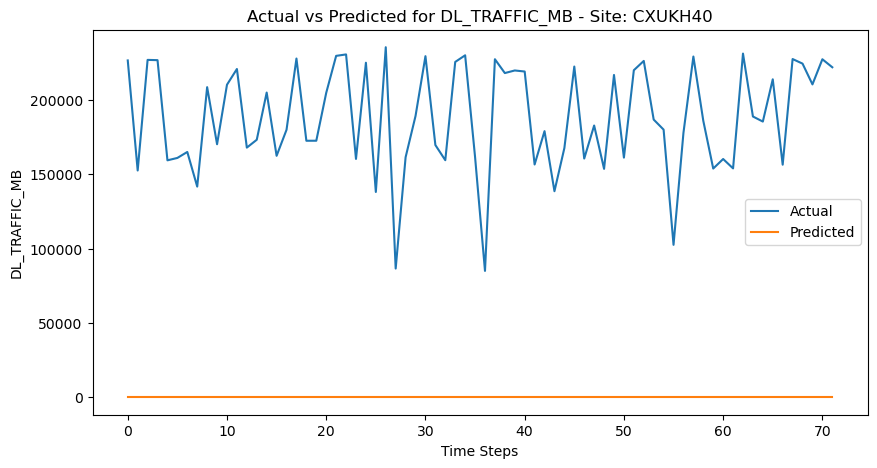

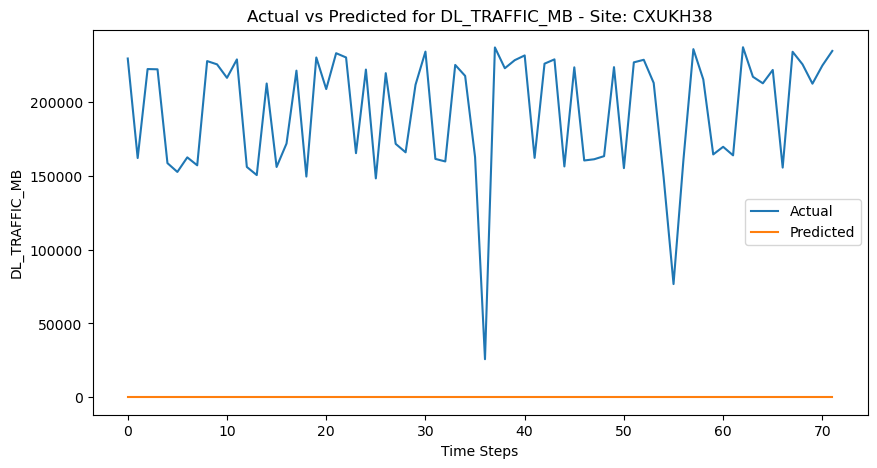

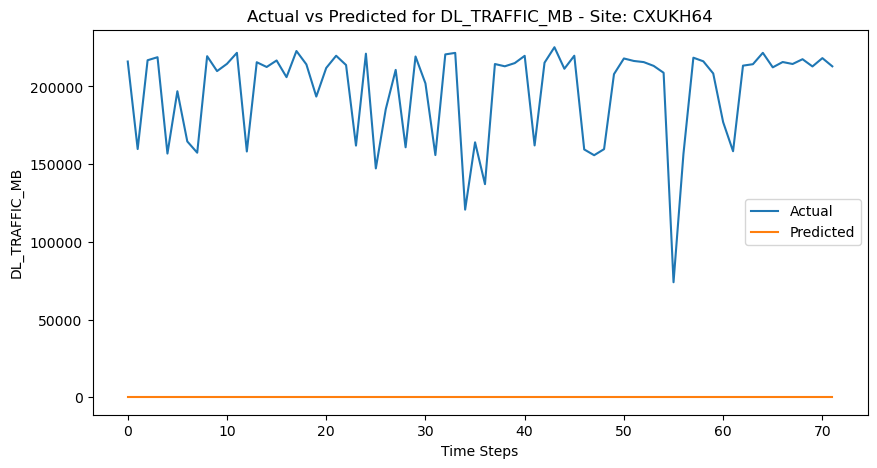

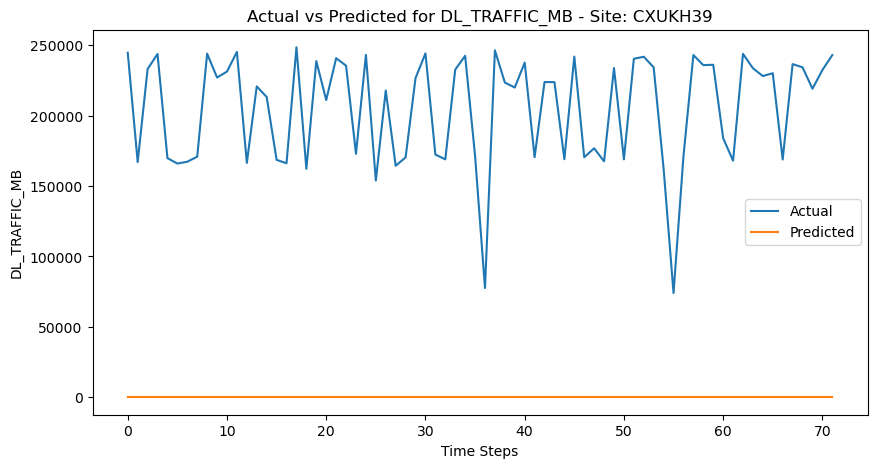

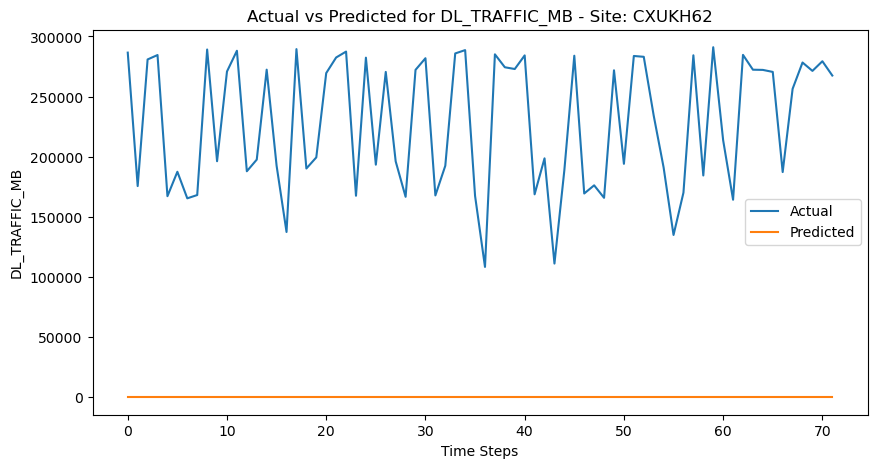

In [9]:
# Plot for the worst 5 sites
for site, _ in worst_5_sites_dl:
    if site in site_predictions_dl_traffic_mb:
        y_test, y_pred = site_predictions_dl_traffic_mb[site]
        plot_actual_vs_predicted(site, y_test, y_pred)
    else:
        print(f"Site {site} not found in site_predictions_dl_traffic_mb.")

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [11]:
# Load the dataset and prepare the data
file_path = '../../data/Data3.csv'
data = pd.read_csv(file_path)
data['Site'] = data['ERBS'].str[:7]
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

# Scaling function
scaler = MinMaxScaler()

# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Function to calculate MSE for each site
def calculate_mse_for_sites(target_column):
    mse_results = {}
    site_predictions = {}
    
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values.reshape(-1, 1)
        if len(site_data) <= 10:
            continue

        # Scale data
        site_data_scaled = scaler.fit_transform(site_data)
        
        # Create sequences
        X, y = create_sequences(site_data_scaled, seq_length=10)
        if len(X) == 0:
            continue
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)
        
        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        mse_results[site] = mse
        site_predictions[site] = (y_test, y_pred)
    
    return mse_results, site_predictions


C:\Users\HP\AppData\Local\Temp\ipykernel_12384\1853146902.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [12]:
# Calculate MSE and predictions for DL_TRAFFIC_MB
mse_results_traffic, site_predictions_traffic = calculate_mse_for_sites('DL_TRAFFIC_MB')


Epoch 1/50
15/15 [==============================] - 9s 207ms/step - loss: 0.1971 - val_loss: 0.0515
Epoch 2/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0232 - val_loss: 0.0164
Epoch 3/50
15/15 [==============================] - 0s 17ms/step - loss: 0.0105 - val_loss: 0.0100
Epoch 4/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0134 - val_loss: 0.0102
Epoch 5/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0109 - val_loss: 0.0108
Epoch 6/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 7/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0121 - val_loss: 0.0098
Epoch 8/50
15/15 [==============================] - 0s 21ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 9/50
15/15 [==============================] - 0s 17ms/step - loss: 0.0097 - val_loss: 0.0098
Epoch 10/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0096 - val_loss: 0.0097
Epoch 11

15/15 [==============================] - 0s 10ms/step - loss: 0.0094 - val_loss: 0.0071
Epoch 14/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0085 - val_loss: 0.0073
Epoch 15/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0088 - val_loss: 0.0073
Epoch 16/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0094 - val_loss: 0.0075
Epoch 17/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0075 - val_loss: 0.0072
Epoch 18/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0091 - val_loss: 0.0083
Epoch 19/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0082 - val_loss: 0.0072
Epoch 20/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0084 - val_loss: 0.0073
Epoch 21/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0090 - val_loss: 0.0070
Epoch 22/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0064 - val_loss: 0.0069
Epoch 23/50


15/15 [==============================] - 0s 11ms/step - loss: 0.0111 - val_loss: 0.0080
Epoch 26/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0131 - val_loss: 0.0079
Epoch 27/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0124 - val_loss: 0.0105
Epoch 28/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0135 - val_loss: 0.0085
Epoch 29/50
15/15 [==============================] - 0s 10ms/step - loss: 0.0126 - val_loss: 0.0086
Epoch 30/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0135 - val_loss: 0.0092
Epoch 31/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0140 - val_loss: 0.0096
Epoch 32/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0123 - val_loss: 0.0080
Epoch 33/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0136 - val_loss: 0.0099
Epoch 34/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0146 - val_loss: 0.0077
Epoch 35/50


15/15 [==============================] - 0s 13ms/step - loss: 0.0099 - val_loss: 0.0102
Epoch 38/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0092 - val_loss: 0.0113
Epoch 39/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0080 - val_loss: 0.0113
Epoch 40/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0087 - val_loss: 0.0100
Epoch 41/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0077 - val_loss: 0.0100
Epoch 42/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0089 - val_loss: 0.0100
Epoch 43/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0093 - val_loss: 0.0103
Epoch 44/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0084 - val_loss: 0.0110
Epoch 45/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0102 - val_loss: 0.0106
Epoch 46/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0082 - val_loss: 0.0100
Epoch 47/50


15/15 [==============================] - 0s 12ms/step - loss: 0.0104 - val_loss: 0.0123
Epoch 50/50
3/3 [==============================] - 1s 3ms/step
Epoch 1/50
15/15 [==============================] - 10s 173ms/step - loss: 0.1860 - val_loss: 0.0594
Epoch 2/50
15/15 [==============================] - 0s 22ms/step - loss: 0.0275 - val_loss: 0.0255
Epoch 3/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0170 - val_loss: 0.0129
Epoch 4/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0142 - val_loss: 0.0130
Epoch 5/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0148 - val_loss: 0.0124
Epoch 6/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0147 - val_loss: 0.0122
Epoch 7/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0147 - val_loss: 0.0126
Epoch 8/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0142 - val_loss: 0.0122
Epoch 9/50
15/15 [==============================] - 0s 

...

15/15 [==============================] - 0s 12ms/step - loss: 0.0128 - val_loss: 0.0028
Epoch 13/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0127 - val_loss: 0.0026
Epoch 14/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0126 - val_loss: 0.0026
Epoch 15/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0123 - val_loss: 0.0026
Epoch 16/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0119 - val_loss: 0.0025
Epoch 17/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0126 - val_loss: 0.0032
Epoch 18/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0126 - val_loss: 0.0042
Epoch 19/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0131 - val_loss: 0.0050
Epoch 20/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0119 - val_loss: 0.0049
Epoch 21/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0126 - val_loss: 0.0024
Epoch 22/50


9/9 [==============================] - 0s 13ms/step - loss: 0.0104 - val_loss: 0.0051
Epoch 25/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0112 - val_loss: 0.0050
Epoch 26/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0090 - val_loss: 0.0055
Epoch 27/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0091 - val_loss: 0.0053
Epoch 28/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0100 - val_loss: 0.0050
Epoch 29/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0075 - val_loss: 0.0051
Epoch 30/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0083 - val_loss: 0.0057
Epoch 31/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0102 - val_loss: 0.0050
Epoch 32/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0098 - val_loss: 0.0051
Epoch 33/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0076 - val_loss: 0.0057
Epoch 34/50
9/9 [===============

15/15 [==============================] - 0s 13ms/step - loss: 0.0164 - val_loss: 0.0050
Epoch 37/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0204 - val_loss: 0.0072
Epoch 38/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0159 - val_loss: 0.0052
Epoch 39/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0159 - val_loss: 0.0044
Epoch 40/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0137 - val_loss: 0.0043
Epoch 41/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0140 - val_loss: 0.0052
Epoch 42/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0176 - val_loss: 0.0043
Epoch 43/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0169 - val_loss: 0.0056
Epoch 44/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0168 - val_loss: 0.0043
Epoch 45/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0180 - val_loss: 0.0047
Epoch 46/50


15/15 [==============================] - 0s 14ms/step - loss: 0.0239 - val_loss: 0.0161
Epoch 49/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0246 - val_loss: 0.0162
Epoch 50/50
3/3 [==============================] - 1s 5ms/step
Epoch 1/50
15/15 [==============================] - 7s 120ms/step - loss: 0.0992 - val_loss: 0.0237
Epoch 2/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0195 - val_loss: 0.0135
Epoch 3/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0129 - val_loss: 0.0078
Epoch 4/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0143 - val_loss: 0.0086
Epoch 5/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0117 - val_loss: 0.0074
Epoch 6/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0133 - val_loss: 0.0093
Epoch 7/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0105 - val_loss: 0.0071
Epoch 8/50
15/15 [==============================] - 0s 

15/15 [==============================] - 0s 12ms/step - loss: 0.0171 - val_loss: 0.0022
Epoch 11/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0139 - val_loss: 0.0034
Epoch 12/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0160 - val_loss: 0.0017
Epoch 13/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0148 - val_loss: 0.0019
Epoch 14/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0151 - val_loss: 0.0014
Epoch 15/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0144 - val_loss: 0.0015
Epoch 16/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0161 - val_loss: 0.0031
Epoch 17/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0135 - val_loss: 0.0014
Epoch 18/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0135 - val_loss: 0.0016
Epoch 19/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0158 - val_loss: 0.0066
Epoch 20/50


In [13]:
# Sort results
sorted_mse_results = sorted(mse_results_traffic.items(), key=lambda x: x[1])
best_5_sites = sorted_mse_results[:5]
worst_5_sites = sorted_mse_results[-5:]


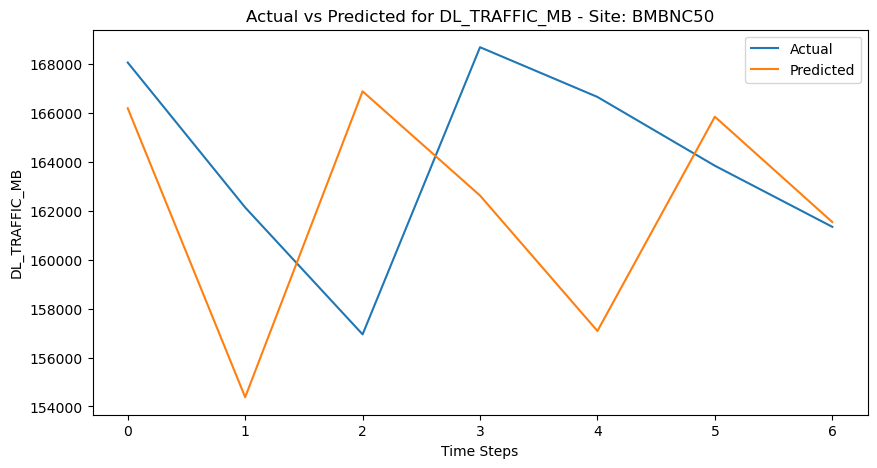

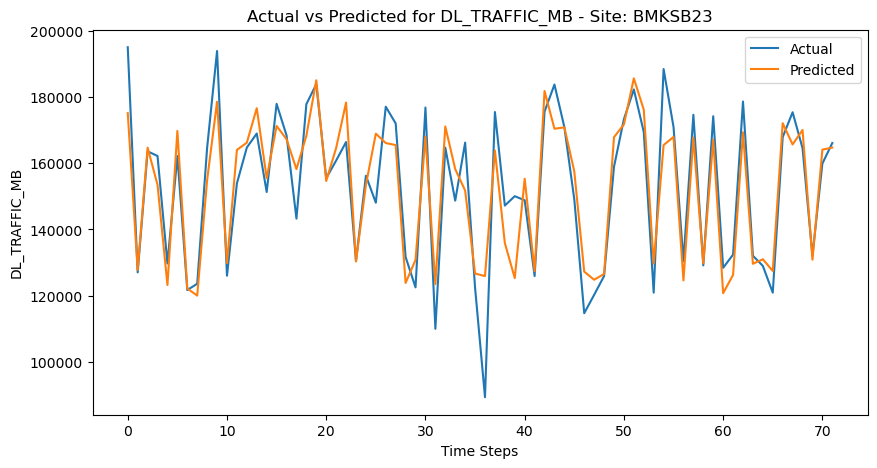

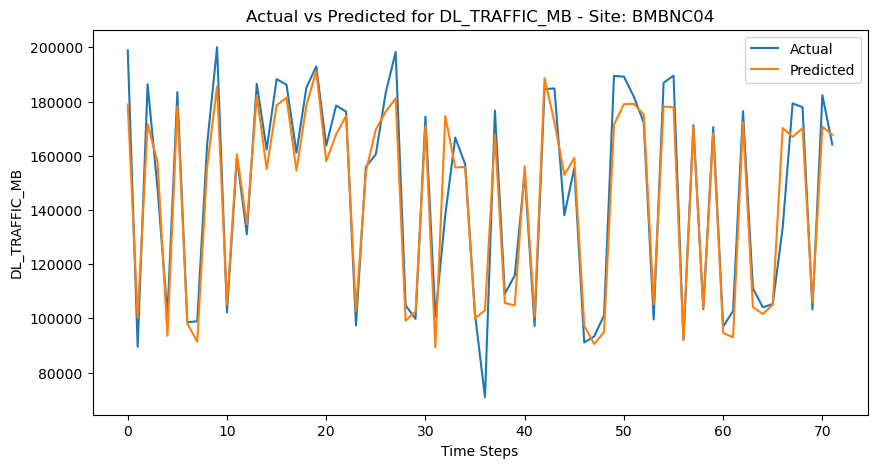

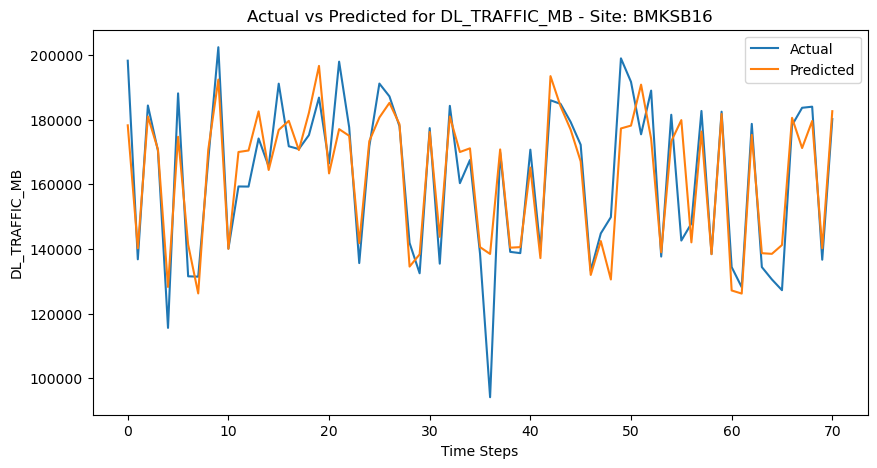

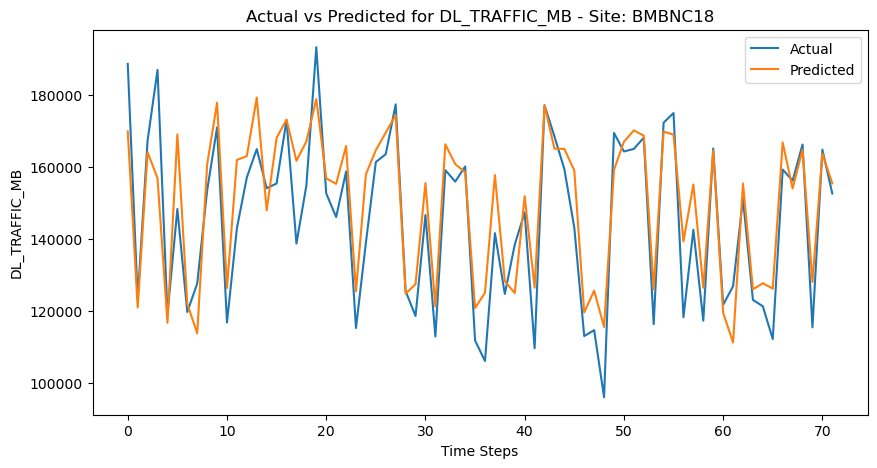

In [14]:
# Plot actual vs predicted values
def plot_actual_vs_predicted(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(scaler.inverse_transform(y_test), label='Actual')
    plt.plot(scaler.inverse_transform(y_pred), label='Predicted')
    plt.title(f'Actual vs Predicted for DL_TRAFFIC_MB - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Plot for best and worst 5 sites
for site, _ in best_5_sites:
    if site in site_predictions_traffic:
        y_test, y_pred = site_predictions_traffic[site]
        plot_actual_vs_predicted(site, y_test, y_pred)

In [15]:
print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

Best 5 Sites based on MSE: [('BMBNC50', 0.0011309747025382972), ('BMKSB23', 0.00261384707110109), ('BMBNC04', 0.0030305368841669683), ('BMKSB16', 0.003137922788711762), ('BMBNC18', 0.0031747863803721615)]
Worst 5 Sites based on MSE: [('CGANW43', 0.02875185748404184), ('BMKSB61', 0.03362773218138811), ('BMKSB57', 0.03418213710392599), ('BMKSB55', 0.04561955203429576), ('BMBNC49', 0.05921046510958605)]


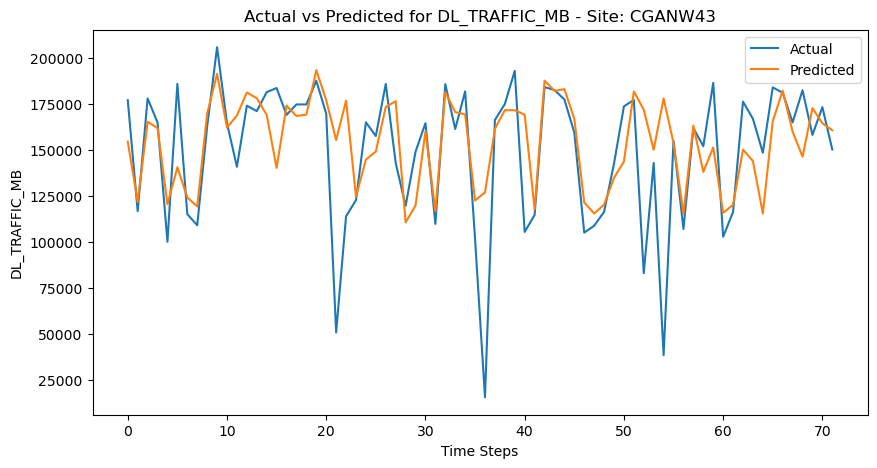

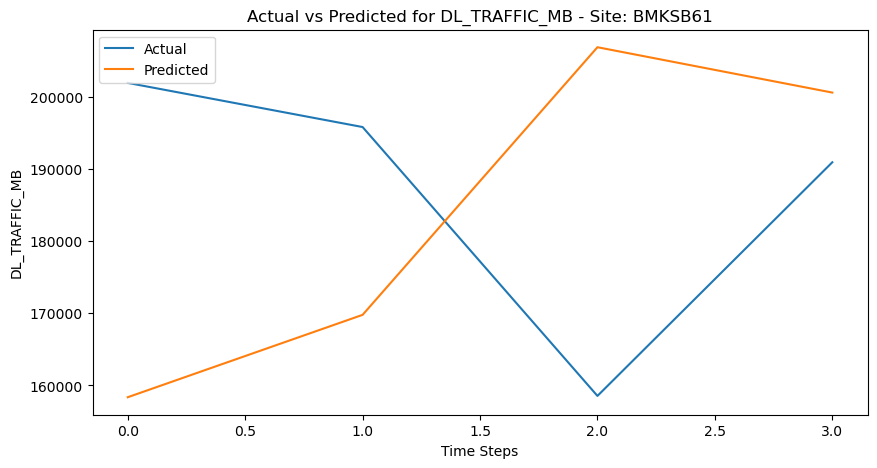

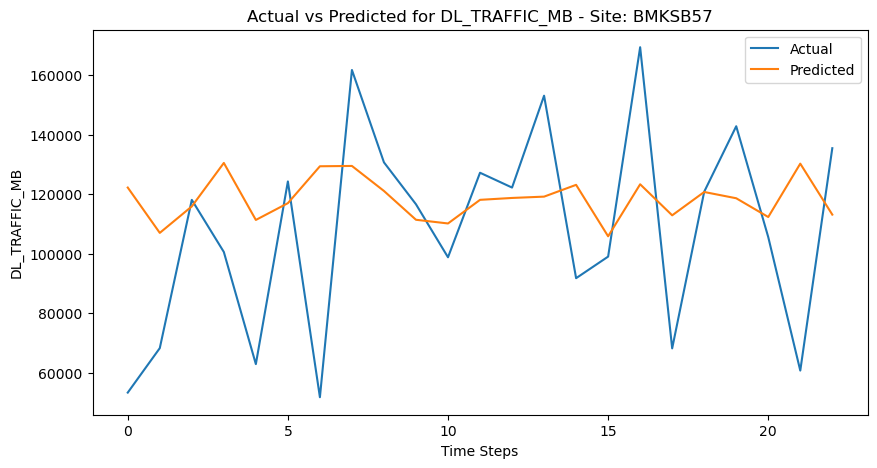

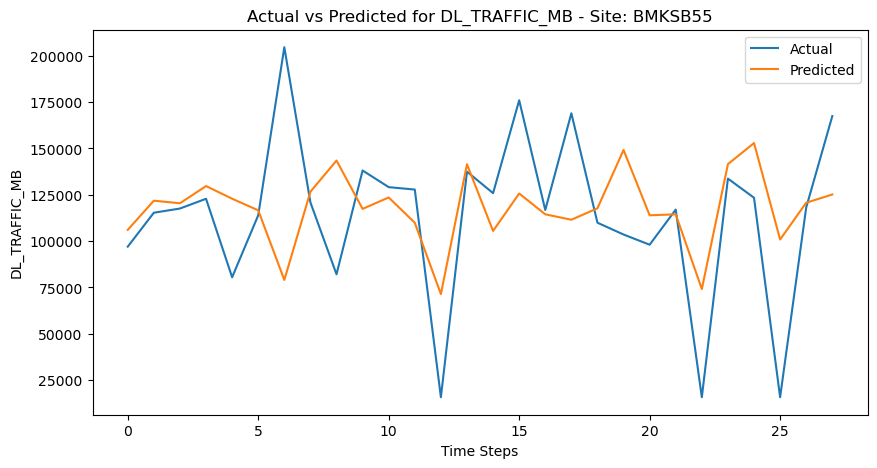

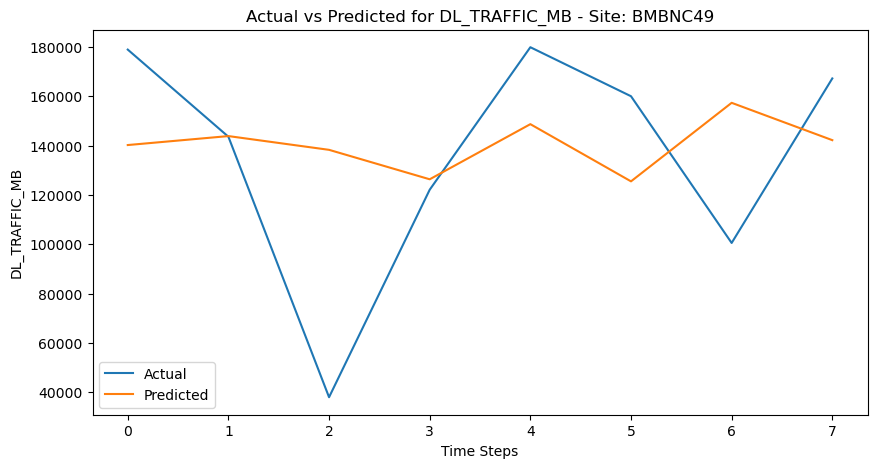

In [16]:
# Plot for worst 5 sites
for site, _ in worst_5_sites:
    if site in site_predictions_traffic:
        y_test, y_pred = site_predictions_traffic[site]
        plot_actual_vs_predicted(site, y_test, y_pred)

C:\Users\HP\AppData\Local\Temp\ipykernel_12384\2069087951.py:16: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


Epoch 1/50
15/15 [==============================] - 77s 354ms/step - loss: 0.2394 - val_loss: 0.0649
Epoch 2/50
15/15 [==============================] - 0s 21ms/step - loss: 0.0304 - val_loss: 0.0255
Epoch 3/50
15/15 [==============================] - 0s 24ms/step - loss: 0.0173 - val_loss: 0.0123
Epoch 4/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0119 - val_loss: 0.0101
Epoch 5/50
15/15 [==============================] - 0s 20ms/step - loss: 0.0109 - val_loss: 0.0102
Epoch 6/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0111 - val_loss: 0.0104
Epoch 7/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 8/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0108 - val_loss: 0.0099
Epoch 9/50
15/15 [==============================] - 0s 26ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 10/50
15/15 [==============================] - 0s 19ms/step - loss: 0.0104 - val_loss: 0.0099
Epoch 1

15/15 [==============================] - 0s 15ms/step - loss: 0.0140 - val_loss: 0.0150
Epoch 33/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0141 - val_loss: 0.0153
Epoch 34/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0136 - val_loss: 0.0195
Epoch 35/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0139 - val_loss: 0.0151
Epoch 36/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0141 - val_loss: 0.0166
Epoch 37/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0126 - val_loss: 0.0146
Epoch 38/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0132 - val_loss: 0.0152
Epoch 39/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0133 - val_loss: 0.0144
Epoch 40/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0131 - val_loss: 0.0156
Epoch 41/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0139 - val_loss: 0.0145
Epoch 42/50


15/15 [==============================] - 0s 12ms/step - loss: 0.0092 - val_loss: 0.0069
Epoch 14/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0083 - val_loss: 0.0075
Epoch 15/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0079 - val_loss: 0.0081
Epoch 16/50
15/15 [==============================] - 0s 19ms/step - loss: 0.0082 - val_loss: 0.0089
Epoch 17/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0087 - val_loss: 0.0070
Epoch 18/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 19/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0090 - val_loss: 0.0078
Epoch 20/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0076 - val_loss: 0.0069
Epoch 21/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0073 - val_loss: 0.0075
Epoch 22/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0060 - val_loss: 0.0070
Epoch 23/50


15/15 [==============================] - 0s 14ms/step - loss: 0.0090 - val_loss: 0.0142
Epoch 45/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0104 - val_loss: 0.0142
Epoch 46/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0126 - val_loss: 0.0142
Epoch 47/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0089 - val_loss: 0.0168
Epoch 48/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0099 - val_loss: 0.0147
Epoch 49/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0089 - val_loss: 0.0150
Epoch 50/50
3/3 [==============================] - 1s 3ms/step
Epoch 1/50
15/15 [==============================] - 10s 144ms/step - loss: 0.2081 - val_loss: 0.0596
Epoch 2/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0252 - val_loss: 0.0190
Epoch 3/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0152 - val_loss: 0.0104
Epoch 4/50
15/15 [==============================] 

...

15/15 [==============================] - 0s 13ms/step - loss: 0.0125 - val_loss: 0.0081
Epoch 18/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0134 - val_loss: 0.0061
Epoch 19/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0143 - val_loss: 0.0059
Epoch 20/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0133 - val_loss: 0.0059
Epoch 21/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0152 - val_loss: 0.0066
Epoch 22/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0123 - val_loss: 0.0065
Epoch 23/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0143 - val_loss: 0.0061
Epoch 24/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0151 - val_loss: 0.0071
Epoch 25/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0176 - val_loss: 0.0087
Epoch 26/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0133 - val_loss: 0.0085
Epoch 27/50


15/15 [==============================] - 0s 12ms/step - loss: 0.0232 - val_loss: 0.0167
Epoch 49/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0227 - val_loss: 0.0170
Epoch 50/50
3/3 [==============================] - 1s 5ms/step
Epoch 1/50
15/15 [==============================] - 7s 117ms/step - loss: 0.1067 - val_loss: 0.0305
Epoch 2/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0198 - val_loss: 0.0170
Epoch 3/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0166 - val_loss: 0.0079
Epoch 4/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0134 - val_loss: 0.0089
Epoch 5/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0123 - val_loss: 0.0076
Epoch 6/50
15/15 [==============================] - 0s 23ms/step - loss: 0.0115 - val_loss: 0.0084
Epoch 7/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0130 - val_loss: 0.0071
Epoch 8/50
15/15 [==============================] - 0s 

15/15 [==============================] - 0s 12ms/step - loss: 0.0132 - val_loss: 0.0057
Epoch 30/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0118 - val_loss: 0.0053
Epoch 31/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0129 - val_loss: 0.0057
Epoch 32/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0123 - val_loss: 0.0056
Epoch 33/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0124 - val_loss: 0.0052
Epoch 34/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0115 - val_loss: 0.0050
Epoch 35/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0125 - val_loss: 0.0049
Epoch 36/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0116 - val_loss: 0.0049
Epoch 37/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0110 - val_loss: 0.0058
Epoch 38/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0144 - val_loss: 0.0049
Epoch 39/50


15/15 [==============================] - 0s 12ms/step - loss: 0.0172 - val_loss: 0.0016
Epoch 11/50
15/15 [==============================] - 0s 16ms/step - loss: 0.0153 - val_loss: 0.0020
Epoch 12/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0158 - val_loss: 0.0016
Epoch 13/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0142 - val_loss: 0.0038
Epoch 14/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0153 - val_loss: 0.0014
Epoch 15/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0164 - val_loss: 0.0026
Epoch 16/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0173 - val_loss: 0.0031
Epoch 17/50
15/15 [==============================] - 0s 12ms/step - loss: 0.0150 - val_loss: 0.0038
Epoch 18/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0149 - val_loss: 0.0056
Epoch 19/50
15/15 [==============================] - 0s 11ms/step - loss: 0.0141 - val_loss: 0.0017
Epoch 20/50


15/15 [==============================] - 0s 14ms/step - loss: 0.0190 - val_loss: 0.0031
Epoch 42/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0154 - val_loss: 0.0027
Epoch 43/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0175 - val_loss: 0.0031
Epoch 44/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0162 - val_loss: 0.0031
Epoch 45/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0176 - val_loss: 0.0037
Epoch 46/50
15/15 [==============================] - 0s 15ms/step - loss: 0.0150 - val_loss: 0.0127
Epoch 47/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0179 - val_loss: 0.0032
Epoch 48/50
15/15 [==============================] - 0s 14ms/step - loss: 0.0168 - val_loss: 0.0029
Epoch 49/50
15/15 [==============================] - 0s 13ms/step - loss: 0.0178 - val_loss: 0.0035
Epoch 50/50
3/3 [==============================] - 1s 4ms/step
Epoch 1/50
15/15 [==============================]

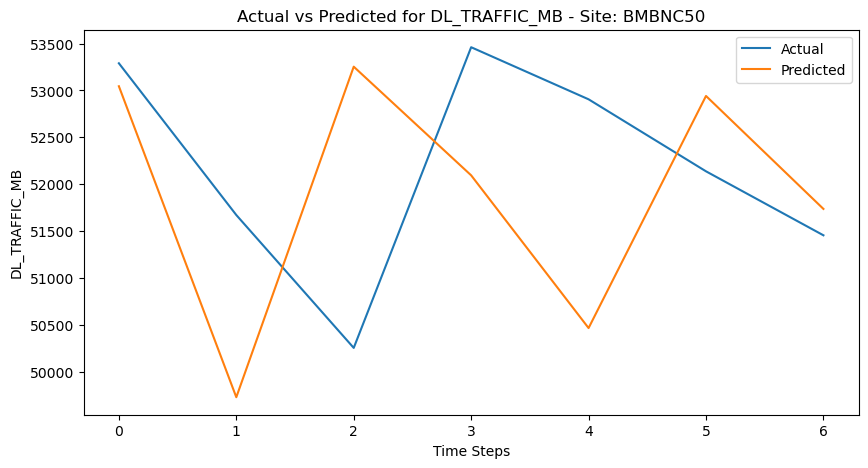

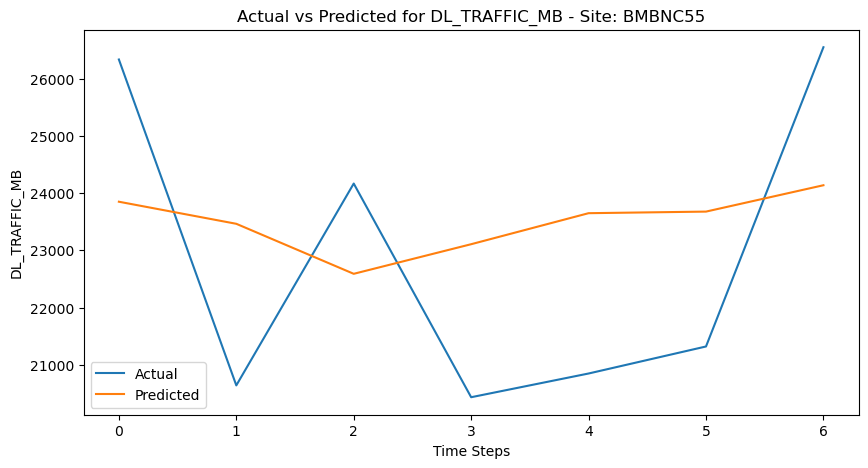

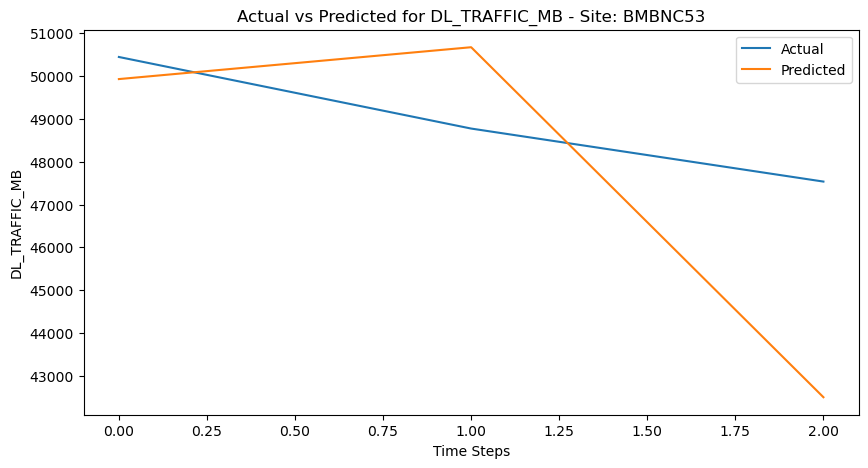

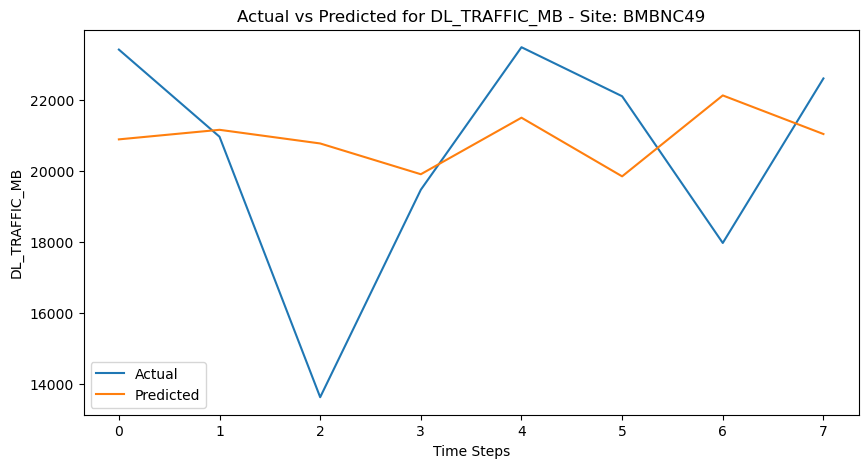

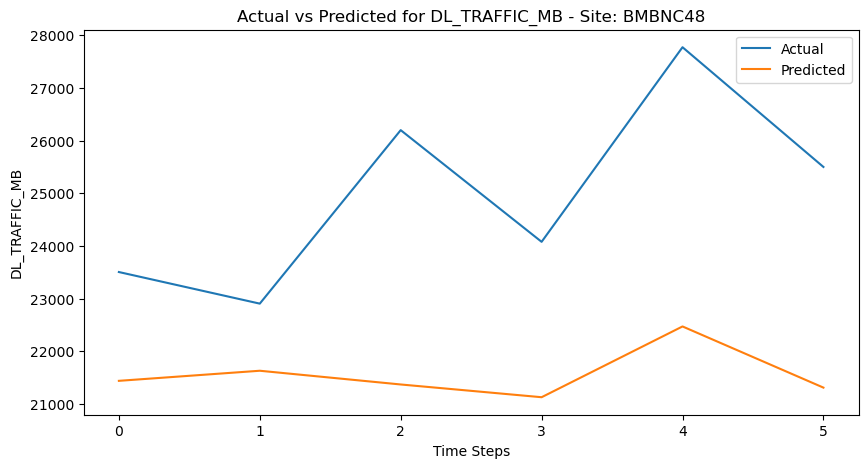

Best 5 Sites based on MSE: [('BMBNC50', 3057870.8820288465), ('BMBNC55', 6133491.532178471), ('BMBNC53', 9743786.460426552), ('BMBNC49', 10784734.858420419), ('BMBNC48', 13912147.75035604)]
Worst 5 Sites based on MSE: [('CGANW69', 745348320.9711399), ('CXUKH32', 754671164.1034399), ('CXUKH62', 760606954.4906523), ('CGANW67', 816884654.332284), ('CXUKH21', 1002770795.2392545)]


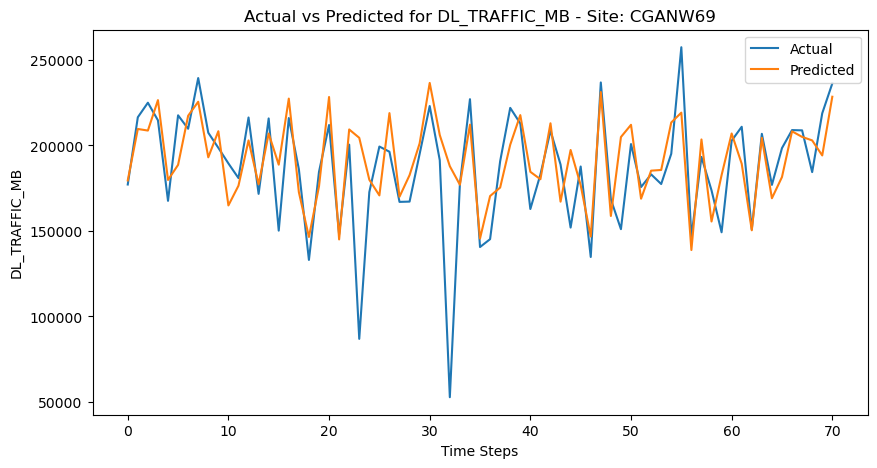

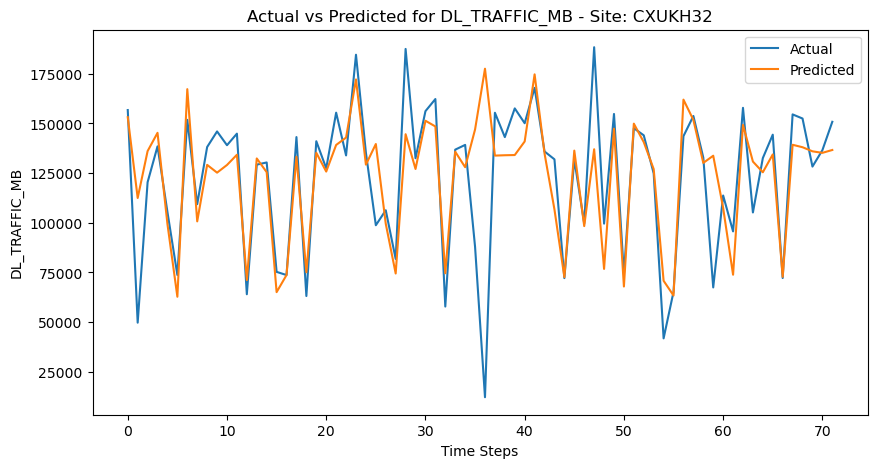

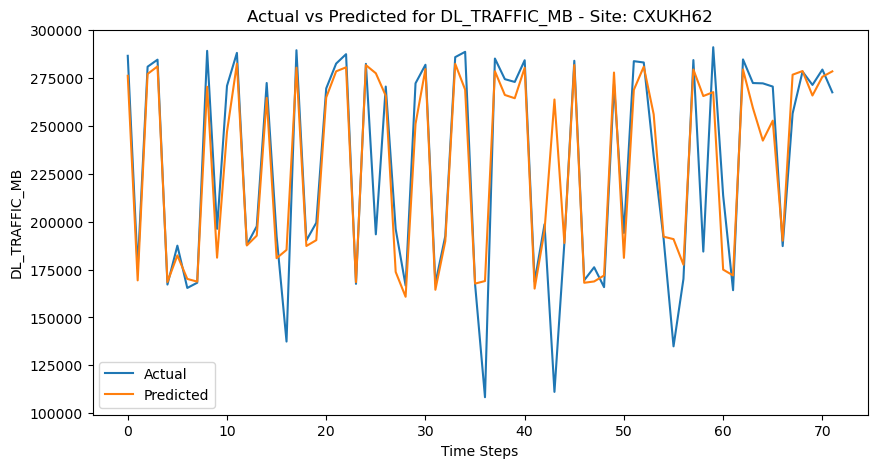

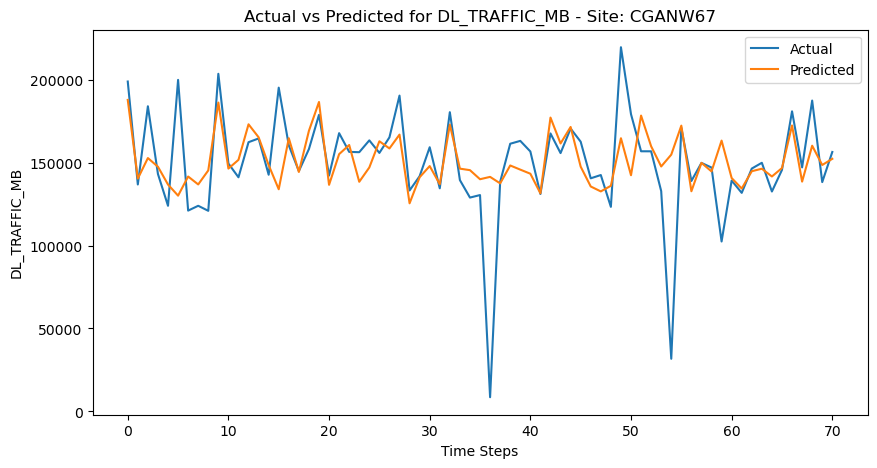

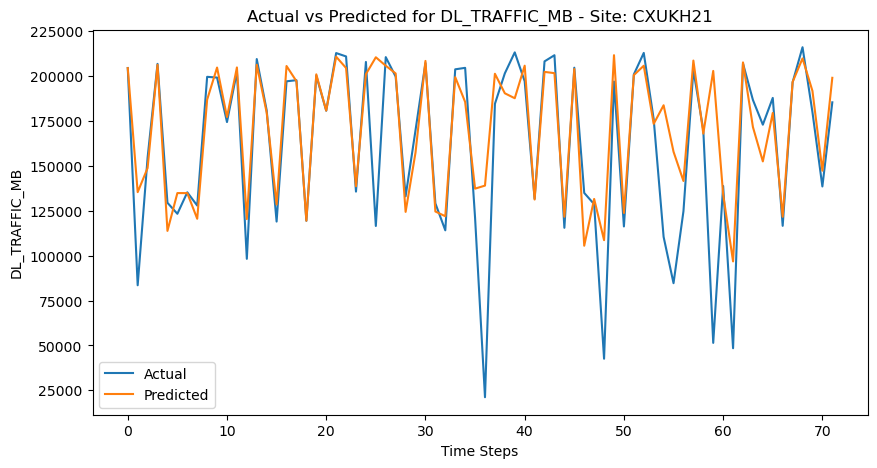

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the dataset and prepare the data
file_path = '../../data/Data3.csv'
data = pd.read_csv(file_path)
data['Site'] = data['ERBS'].str[:7]
data['STARTTIME_DATE'] = pd.to_datetime(data['STARTTIME_DATE'])
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

# Scaling function
scaler = MinMaxScaler()

# Define the create_sequences function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Function to calculate MSE for each site
def calculate_mse_for_sites(target_column):
    mse_results = {}
    site_predictions = {}
    
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values.reshape(-1, 1)
        if len(site_data) <= 10:
            continue

        # Scale data
        site_data_scaled = scaler.fit_transform(site_data)
        
        # Create sequences
        X, y = create_sequences(site_data_scaled, seq_length=10)
        if len(X) == 0:
            continue
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Define and train the LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Inverse transform the predictions and true values before calculating MSE
        y_test_inverse = scaler.inverse_transform(y_test)
        y_pred_inverse = scaler.inverse_transform(y_pred)
        
        # Calculate MSE on the inverse-transformed data
        mse = mean_squared_error(y_test_inverse, y_pred_inverse)
        
        mse_results[site] = mse
        site_predictions[site] = (y_test_inverse, y_pred_inverse)
    
    return mse_results, site_predictions


# Calculate MSE and predictions for DL_TRAFFIC_MB
mse_results_traffic, site_predictions_traffic = calculate_mse_for_sites('DL_TRAFFIC_MB')


# Sort results
sorted_mse_results = sorted(mse_results_traffic.items(), key=lambda x: x[1])
best_5_sites = sorted_mse_results[:5]
worst_5_sites = sorted_mse_results[-5:]


# Plot actual vs predicted values
def plot_actual_vs_predicted(site, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for DL_TRAFFIC_MB - Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Plot for best and worst 5 sites
for site, _ in best_5_sites:
    if site in site_predictions_traffic:
        y_test, y_pred = site_predictions_traffic[site]
        plot_actual_vs_predicted(site, y_test, y_pred)

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

# Plot for worst 5 sites
for site, _ in worst_5_sites:
    if site in site_predictions_traffic:
        y_test, y_pred = site_predictions_traffic[site]
        plot_actual_vs_predicted(site, y_test, y_pred)


In [18]:
print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

Best 5 Sites based on MSE: [('BMBNC50', 3057870.8820288465), ('BMBNC55', 6133491.532178471), ('BMBNC53', 9743786.460426552), ('BMBNC49', 10784734.858420419), ('BMBNC48', 13912147.75035604)]
Worst 5 Sites based on MSE: [('CGANW69', 745348320.9711399), ('CXUKH32', 754671164.1034399), ('CXUKH62', 760606954.4906523), ('CGANW67', 816884654.332284), ('CXUKH21', 1002770795.2392545)]
